In [1]:
from dotenv import load_dotenv
# from prompts import AGENT_PROMPT
from tools import tools, create_fresh_calendar_service
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI
from tools import google_search, rag_retrieval
from langgraph.graph.message import add_messages
from typing import Annotated, Sequence, TypedDict
from langgraph.graph import StateGraph, START, END
# from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, BaseMessage
from datetime import datetime
load_dotenv(override=True)

for tool in tools:
    if hasattr(tool, "_run"):
        original_run = tool._run
        
        def make_safe_run(original_run, tool_obj=tool):
            def safe_run(*args, **kwargs):
                # Force fresh service before every API call
                fresh_service = create_fresh_calendar_service()
                
                # Patch the resource if it exists
                if hasattr(tool_obj, "api_resource"):
                    tool_obj.api_resource = fresh_service
                
                # Some tools store it as _service or similar
                if hasattr(tool_obj, "_service"):
                    tool_obj._service = fresh_service
                
                return original_run(*args, **kwargs)
            return safe_run
        
        tool._run = make_safe_run(original_run)


tools.append(google_search)
tools.append(rag_retrieval)

# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0,
#     streaming = True
# ).bind_tools(tools)

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    streaming=True
).bind_tools(tools)

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


async def agent_node(state: AgentState) -> AgentState:
    print("********AGENT********")
    print(state["messages"][-10:])
    print('\n')
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    system_prompt = SystemMessage(
        content=f"You are a helpful assistant that answers the user's question accurately. Current time: {current_time}"
    )
    response = await llm.ainvoke([system_prompt] + state["messages"][-10:])
    
    return {"messages": [response]}


def should_continue(state):
    last = state["messages"][-1]
    if getattr(last, "tool_calls", None):
        print("\n🔍 ROUTER DEBUG")
        print("TOOL CALLS:", getattr(last, "tool_calls", None))
        return "tool_call"

    return "end"
    
# Graph Builder
graph_builder = StateGraph(AgentState)
graph_builder.add_node("agent", agent_node)
tool_node = ToolNode(tools = tools)
graph_builder.add_node("tools", tool_node)


graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tool_call": "tools",
        "end": END
    }
)
graph_builder.add_edge("tools", "agent")

my_graph = graph_builder.compile()

/home/ali/AI/8.NevTech/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1074: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/home/ali/AI/8.NevTech/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1132: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


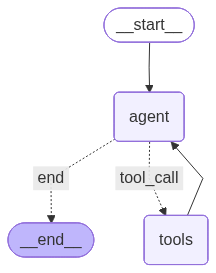

In [2]:
my_graph